In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_resnet1d, plot_loss_vs_epoch, evaluate_resnet_vitaldb, train_resnet1d_se, train_resnet1d_cbam, train_resnet1d_dilated

In [3]:
WINDOW_SIZE = 625
STEP_SIZE = 625

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_0overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:44<00:00, 91.80it/s] 


Skipped recordings: 96


100%|██████████| 1200/1200 [00:13<00:00, 87.29it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:13<00:00, 86.60it/s]

Skipped recordings: 9


Device: cuda
X_train: torch.Size([417030, 1, 625])
y_train: torch.Size([417030, 2])
X_val: torch.Size([52650, 1, 625])
y_val: torch.Size([52650, 2])
X_test: torch.Size([52863, 1, 625])
y_test: torch.Size([52863, 2])
Epoch 01/100 | Train Loss: 5643.9842 | Val Loss: 1876.7362 | Train SBP RMSE: 97.714 | Train DBP RMSE: 41.713 | Val SBP RMSE: 59.658 | Val DBP RMSE: 13.942 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 493.6981 | Val Loss: 204.4494 | Train SBP RMSE: 29.671 | Train DBP RMSE: 10.345 | Val SBP RMSE: 17.808 | Val DBP RMSE: 9.581 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 196.2762 | Val Loss: 194.4102 | Train SBP RMSE: 17.272 | Train DBP RMSE: 9.708 | Val SBP RMSE: 17.592 | Val DBP RMSE: 8.907 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 175.2711 | Val Loss: 175.9452 | Train SBP RMSE: 16.300 | Train DBP RMSE: 9.212 | Val SBP RMSE: 16.559 | Val DBP RMSE: 8.813 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 161.4117 | Val Loss: 193.8538 | Train SBP RMSE: 15.605 | Train DBP RMSE: 8.905 | Val SBP

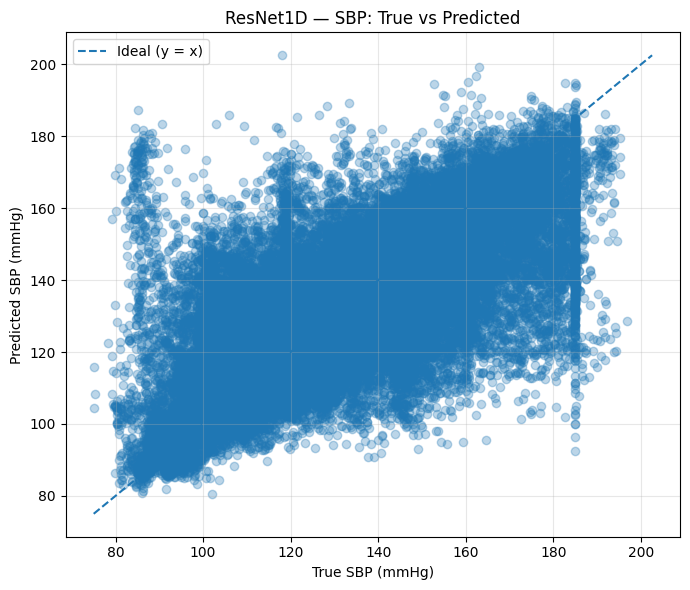

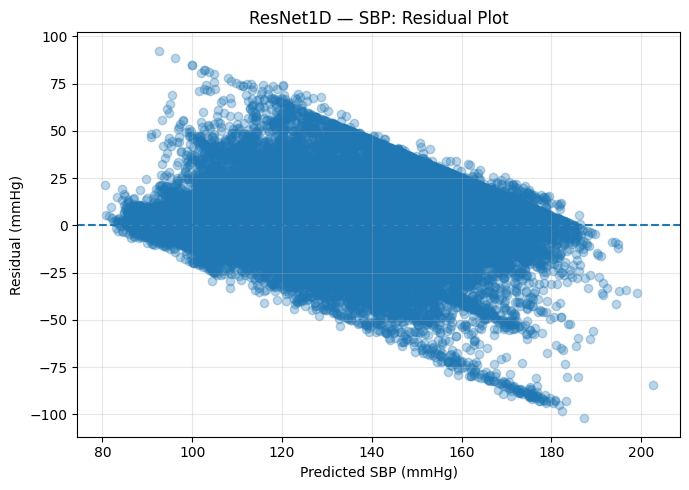

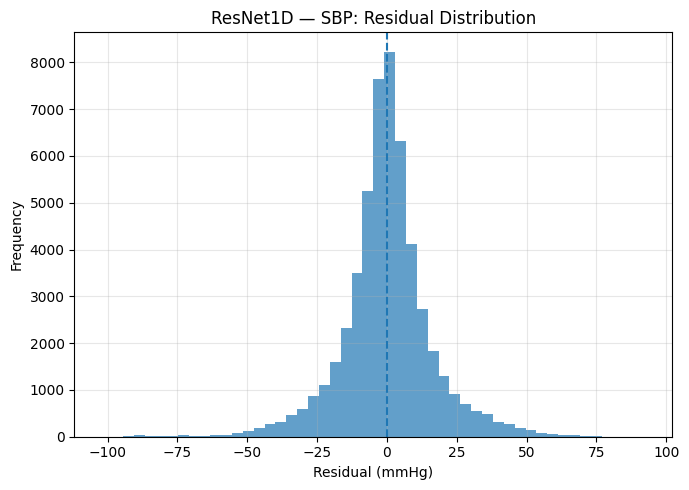

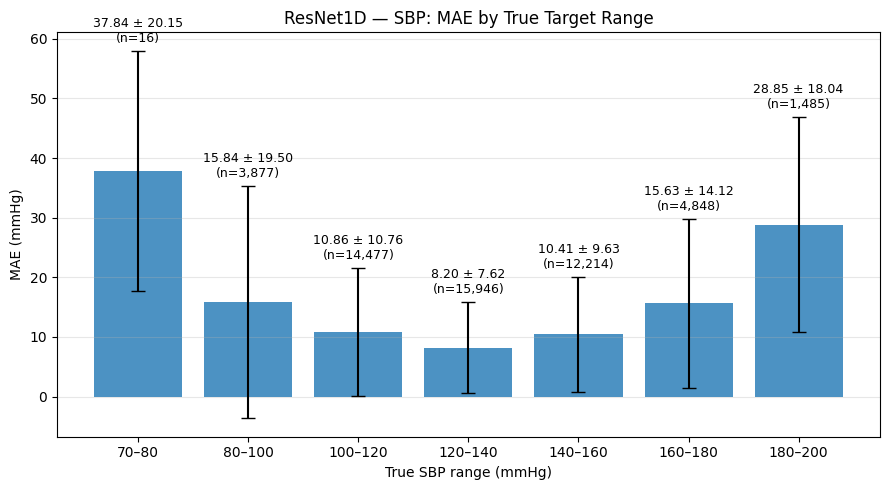

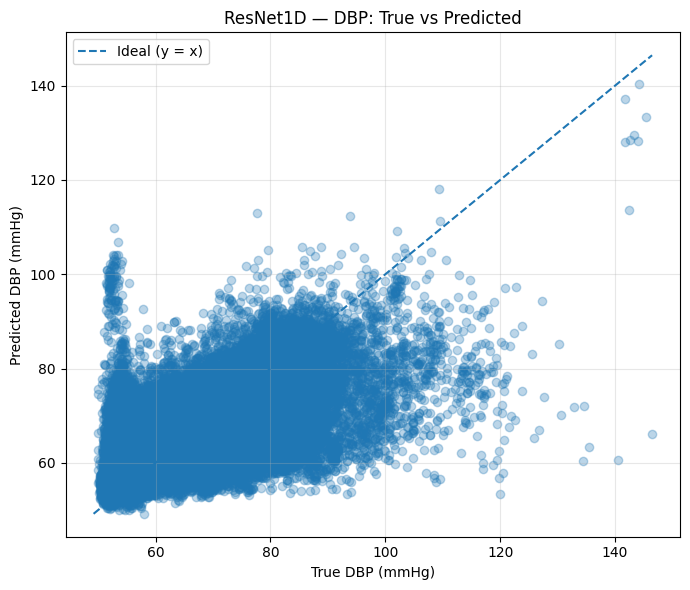

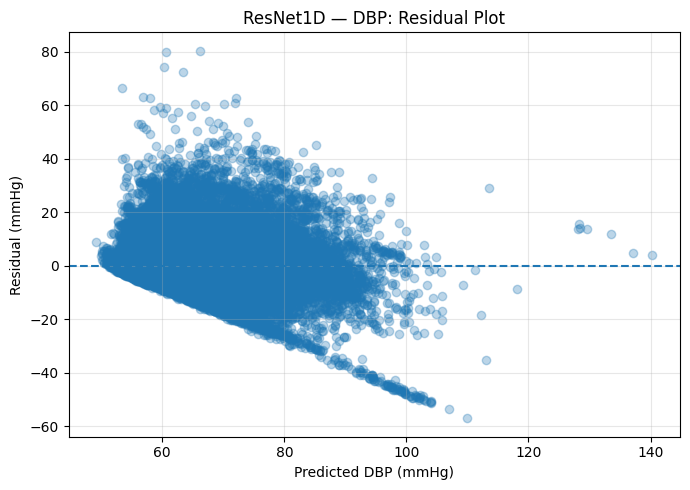

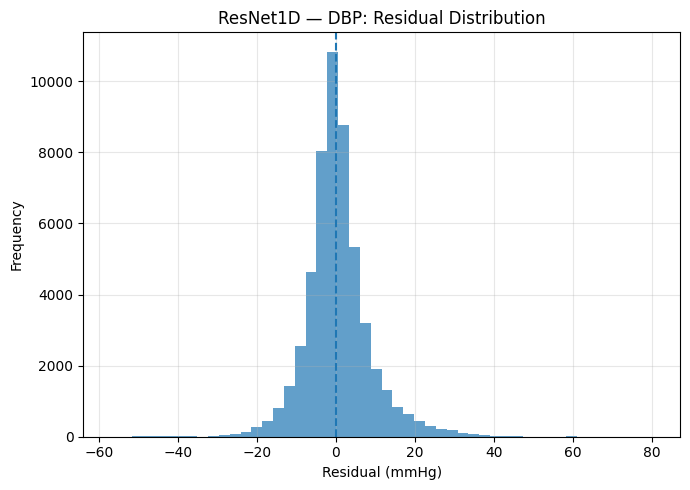

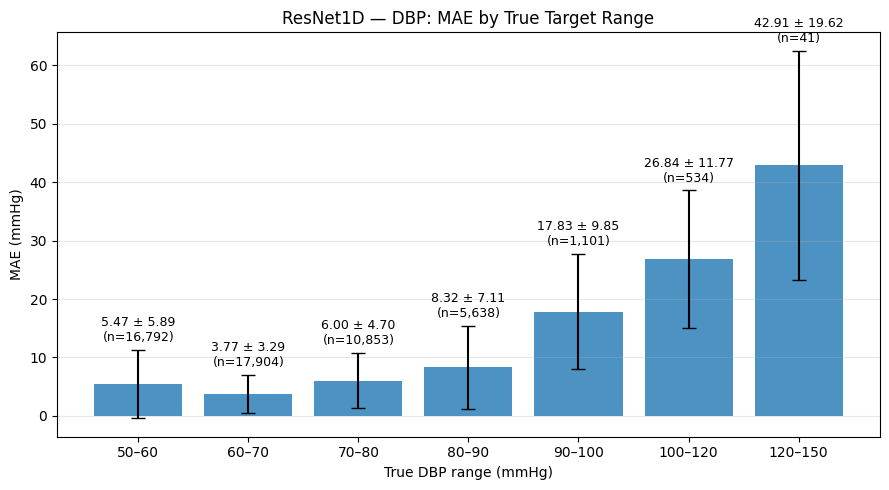

In [4]:
resnet_model, resnet_results = train_resnet1d(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

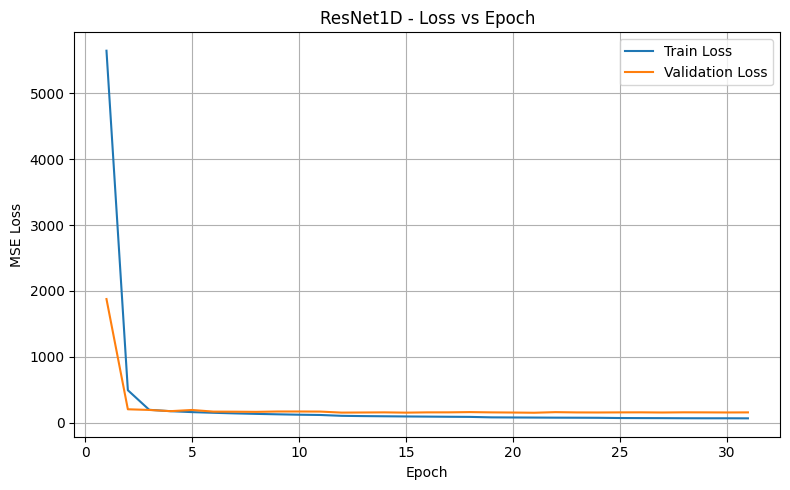

In [5]:
plot_loss_vs_epoch(
    resnet_results["history"],
    model_name="ResNet1D"
)

Number of VitalDB cases: 1961


ResNet1D VitalDB prediction: 100%|██████████| 1961/1961 [07:22<00:00,  4.43case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 27.6816
MSE : 766.2720
R²  : -0.7984
MAE : 21.9625

DBP
RMSE: 14.6231
MSE : 213.8363
R²  : -0.3138
MAE : 11.4812


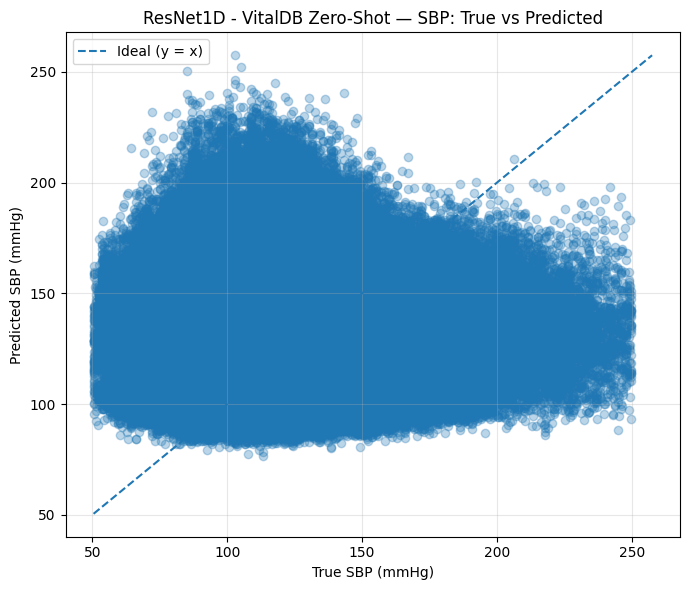

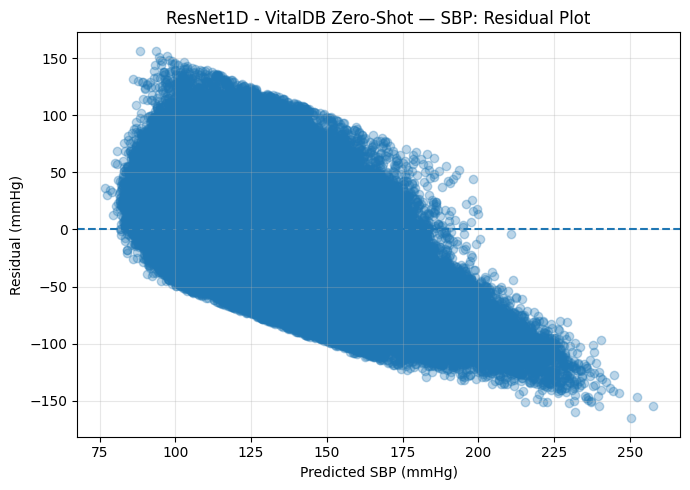

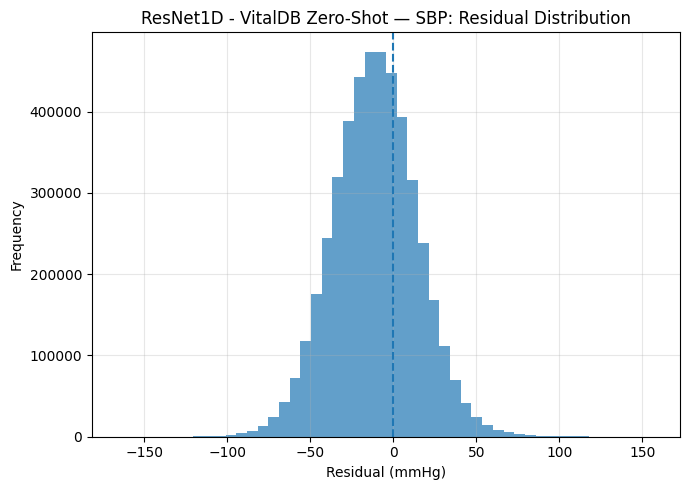

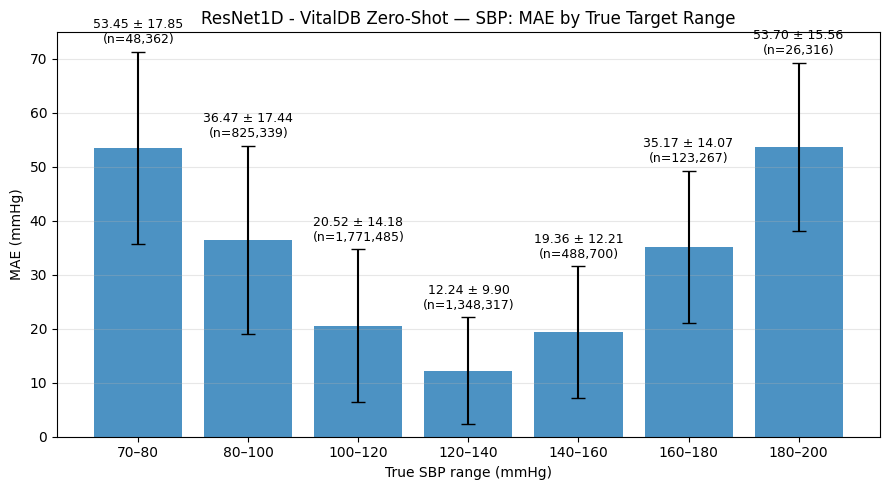

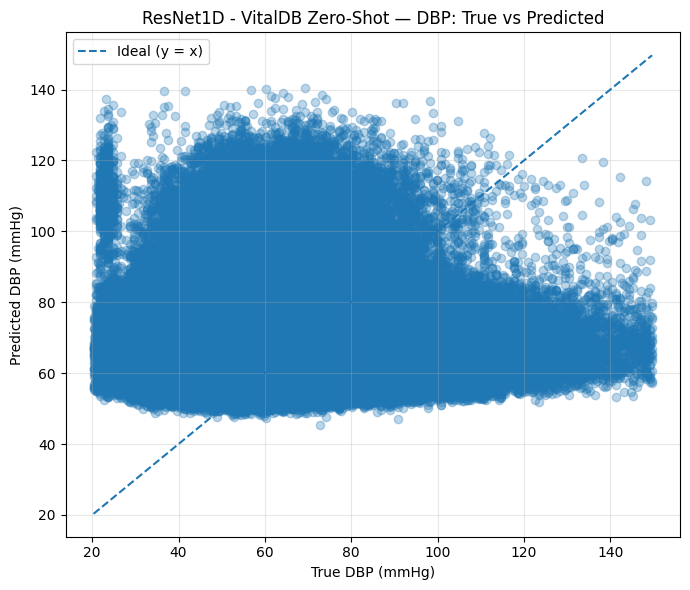

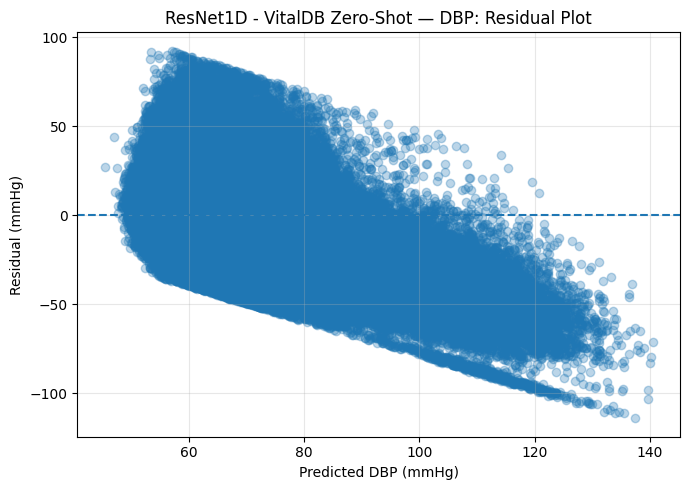

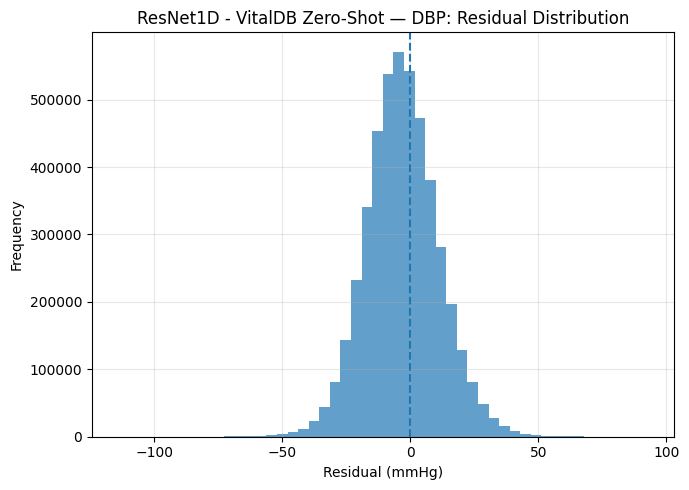

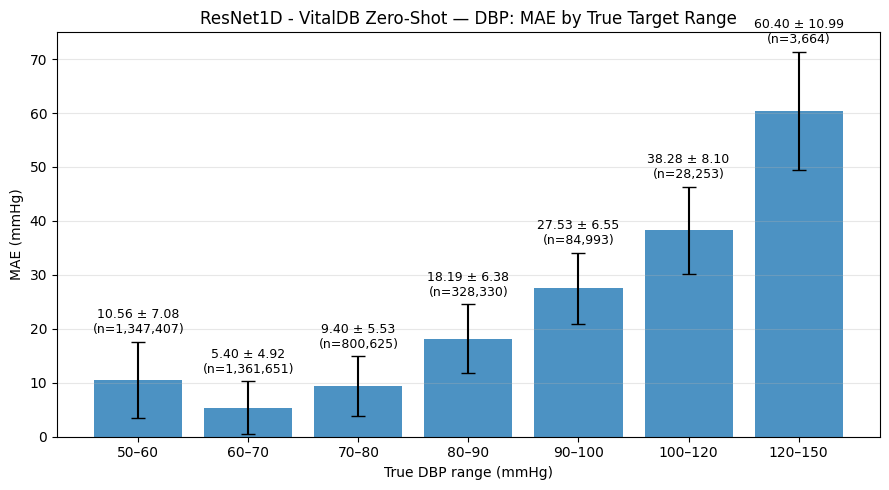

In [6]:
resnet_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## SE Activation ##

Device: cuda
X_train: torch.Size([417030, 1, 625])
y_train: torch.Size([417030, 2])
X_val: torch.Size([52650, 1, 625])
y_val: torch.Size([52650, 2])
X_test: torch.Size([52863, 1, 625])
y_test: torch.Size([52863, 2])
Epoch 01/100 | Train Loss: 6505.6460 | Val Loss: 2791.1289 | Train SBP RMSE: 104.323 | Train DBP RMSE: 46.129 | Val SBP RMSE: 71.920 | Val DBP RMSE: 20.243 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 1286.7950 | Val Loss: 243.4911 | Train SBP RMSE: 48.969 | Train DBP RMSE: 13.254 | Val SBP RMSE: 19.385 | Val DBP RMSE: 10.545 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 267.4932 | Val Loss: 221.6606 | Train SBP RMSE: 20.508 | Train DBP RMSE: 10.696 | Val SBP RMSE: 18.725 | Val DBP RMSE: 9.627 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 228.8495 | Val Loss: 196.7719 | Train SBP RMSE: 18.831 | Train DBP RMSE: 10.154 | Val SBP RMSE: 17.591 | Val DBP RMSE: 9.171 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 202.7922 | Val Loss: 228.8054 | Train SBP RMSE: 17.653 | Train DBP RMSE: 9.692 | Va

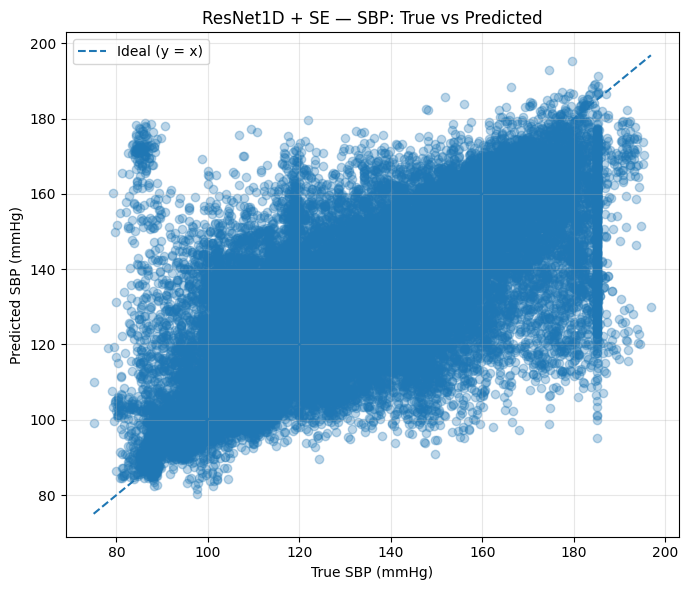

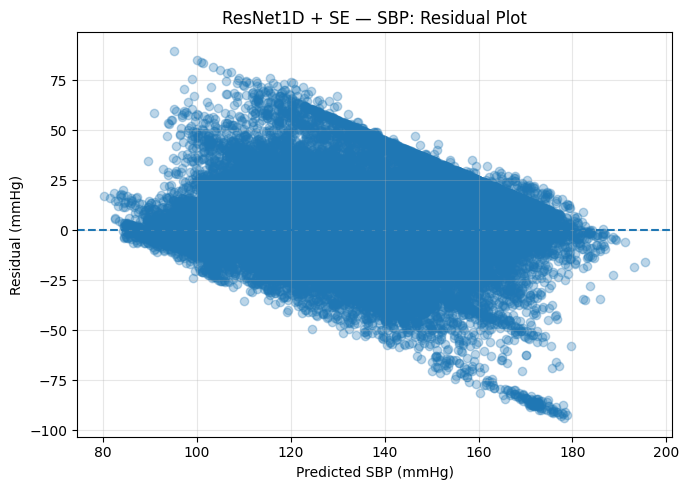

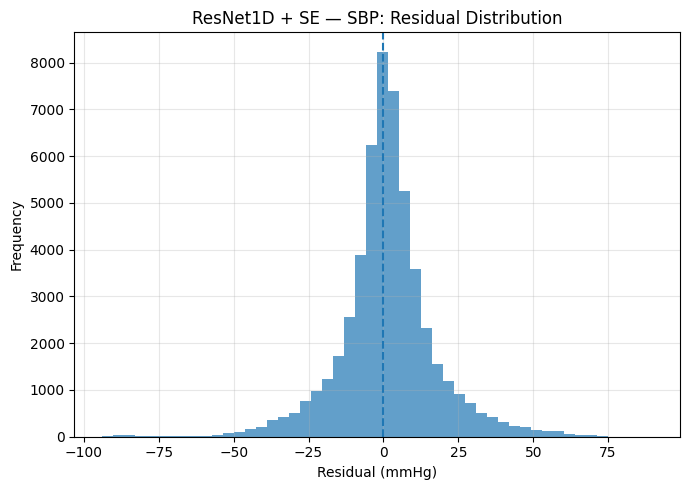

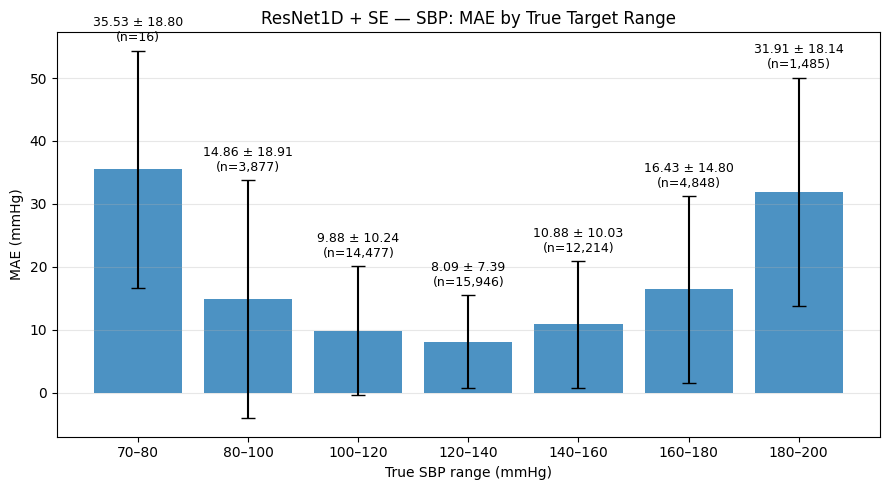

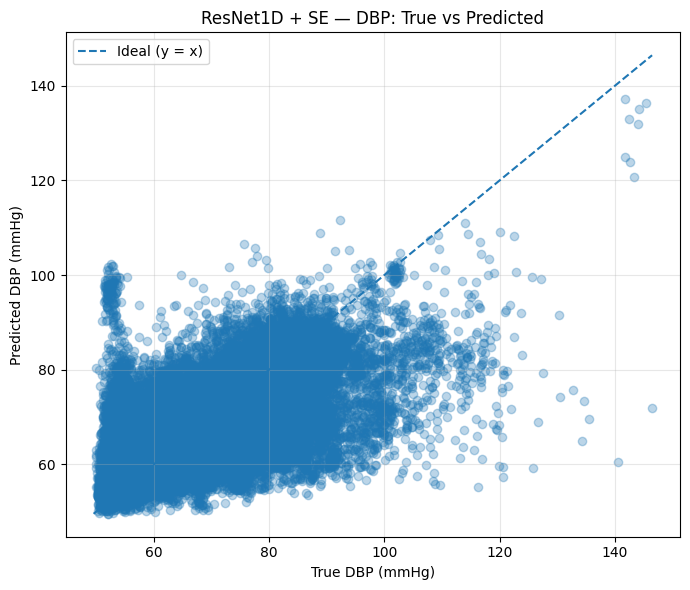

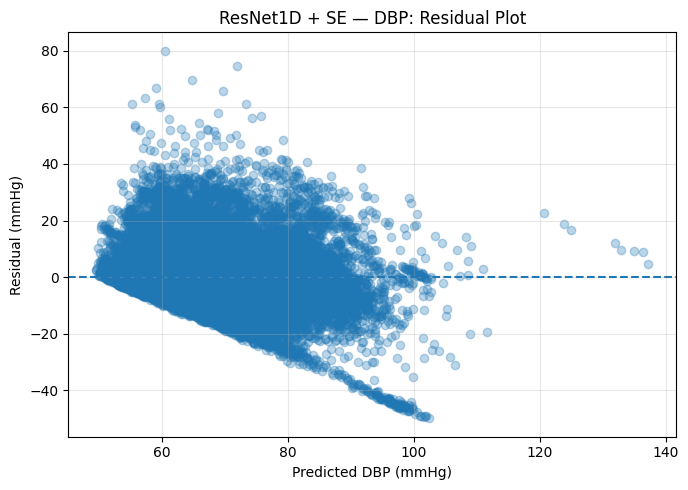

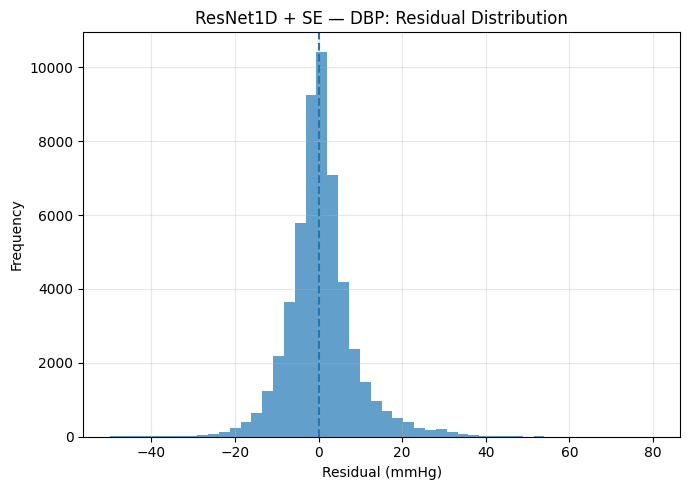

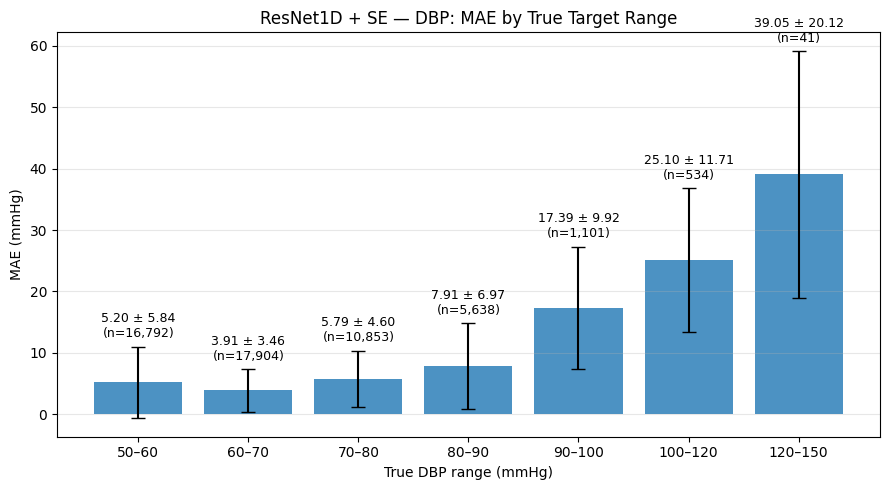

In [7]:
resnet_se_model, resnet_se_results = train_resnet1d_se(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10,
    reduction=16
)

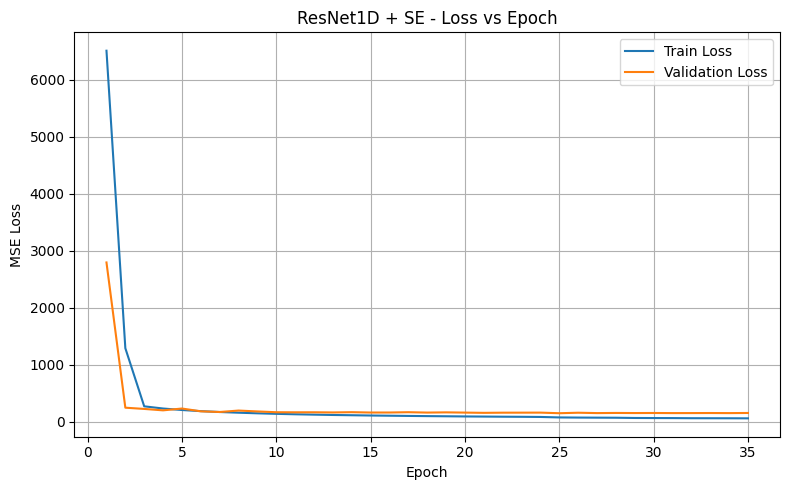

In [8]:
plot_loss_vs_epoch(
    resnet_se_results["history"],
    model_name="ResNet1D + SE"
)

Number of VitalDB cases: 1961


ResNet1D VitalDB prediction: 100%|██████████| 1961/1961 [05:28<00:00,  5.97case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 28.7438
MSE : 826.2065
R²  : -0.9391
MAE : 23.0373

DBP
RMSE: 15.6500
MSE : 244.9212
R²  : -0.5047
MAE : 12.3660


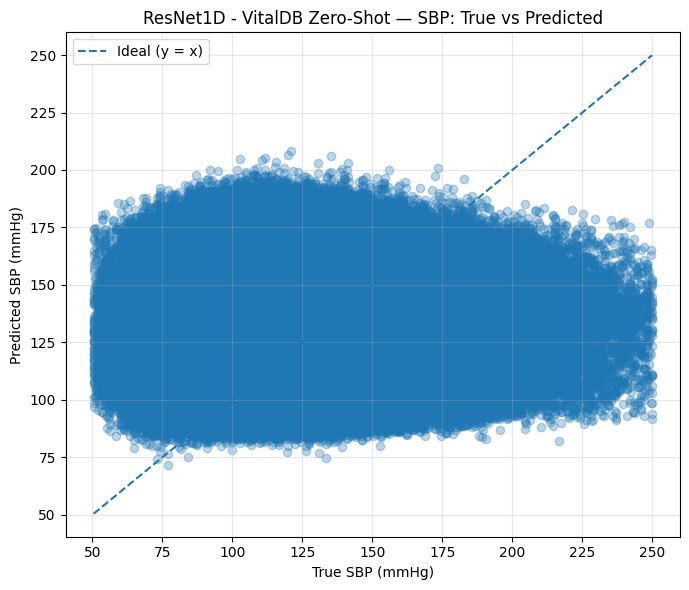

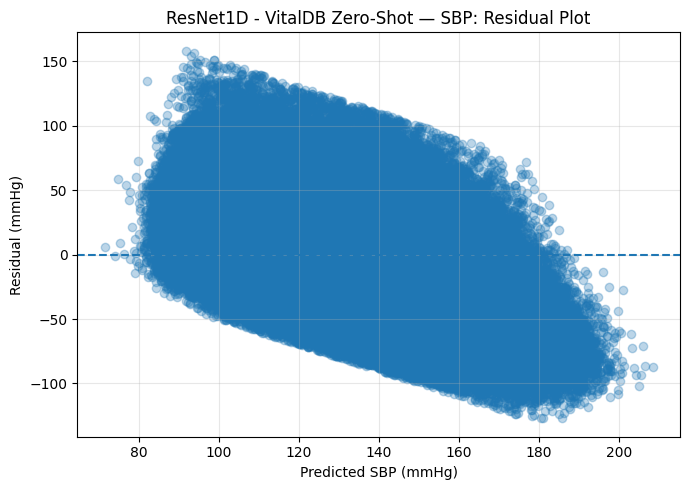

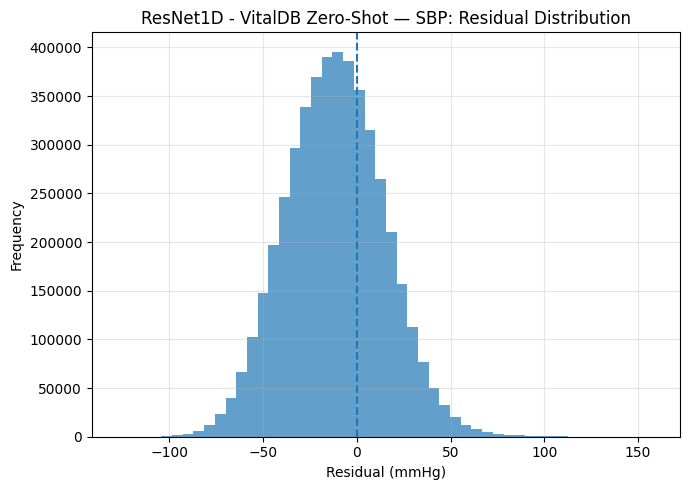

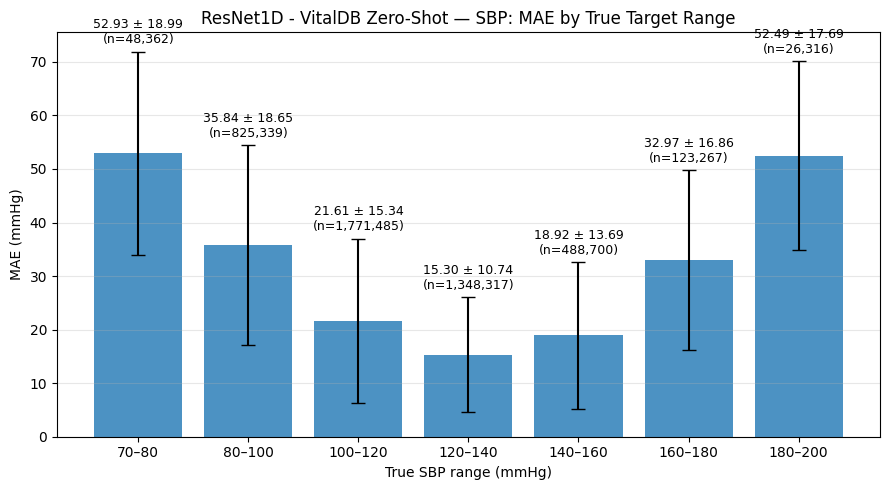

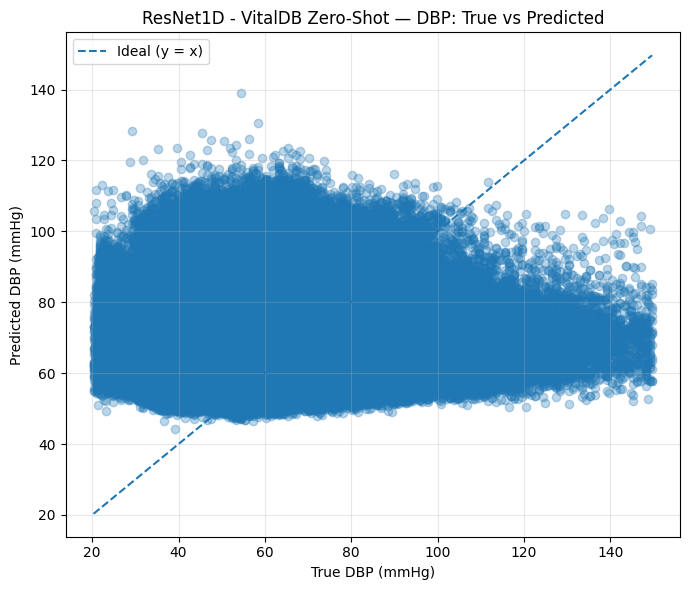

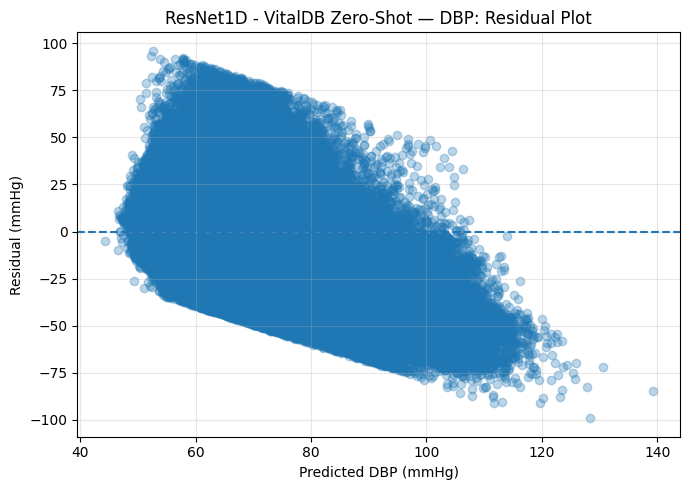

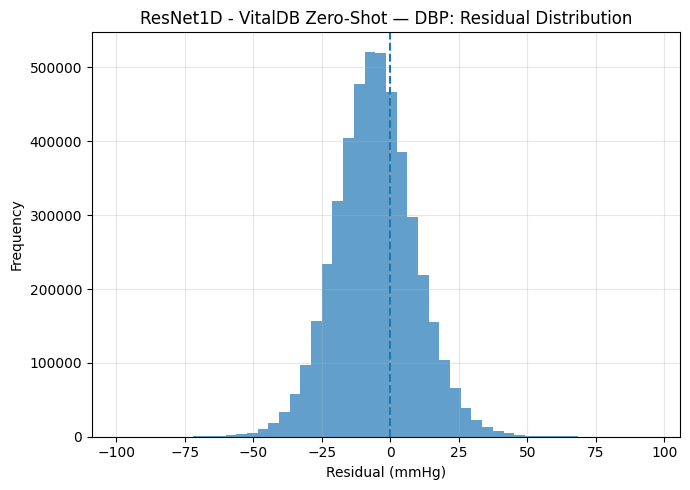

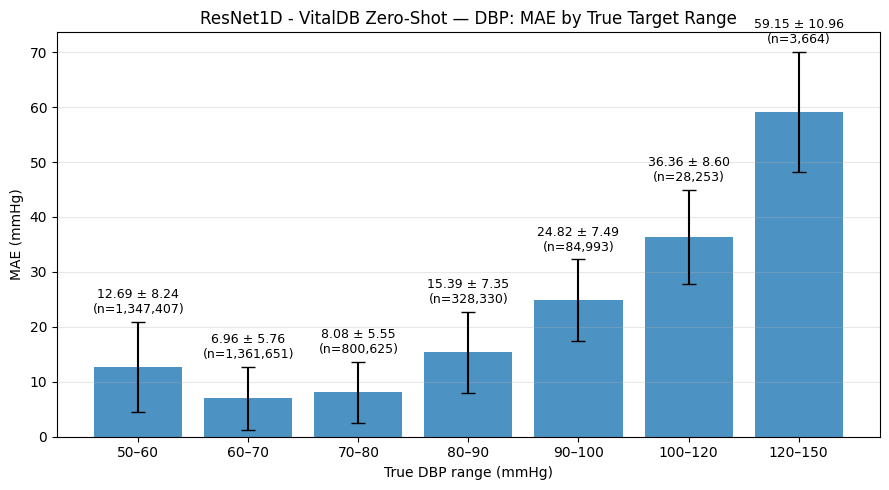

In [9]:
resnet_se_vitaldb_results = evaluate_resnet_vitaldb(
    model=resnet_se_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## CBAM ##

Device: cuda
X_train: torch.Size([417030, 1, 625])
X_val: torch.Size([52650, 1, 625])
X_test: torch.Size([52863, 1, 625])
Epoch 01/100 | Train Loss: 6284.9111 | Val Loss: 2049.6950 | Train SBP RMSE: 102.829 | Train DBP RMSE: 44.678 | Val SBP RMSE: 62.232 | Val DBP RMSE: 15.053 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 509.4652 | Val Loss: 200.3422 | Train SBP RMSE: 30.126 | Train DBP RMSE: 10.554 | Val SBP RMSE: 17.576 | Val DBP RMSE: 9.580 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 207.6064 | Val Loss: 190.5341 | Train SBP RMSE: 17.838 | Train DBP RMSE: 9.850 | Val SBP RMSE: 17.339 | Val DBP RMSE: 8.969 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 187.0514 | Val Loss: 187.2199 | Train SBP RMSE: 16.912 | Train DBP RMSE: 9.385 | Val SBP RMSE: 17.204 | Val DBP RMSE: 8.858 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 170.9779 | Val Loss: 175.6274 | Train SBP RMSE: 16.106 | Train DBP RMSE: 9.086 | Val SBP RMSE: 16.291 | Val DBP RMSE: 9.267 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 158.5440 | Val 

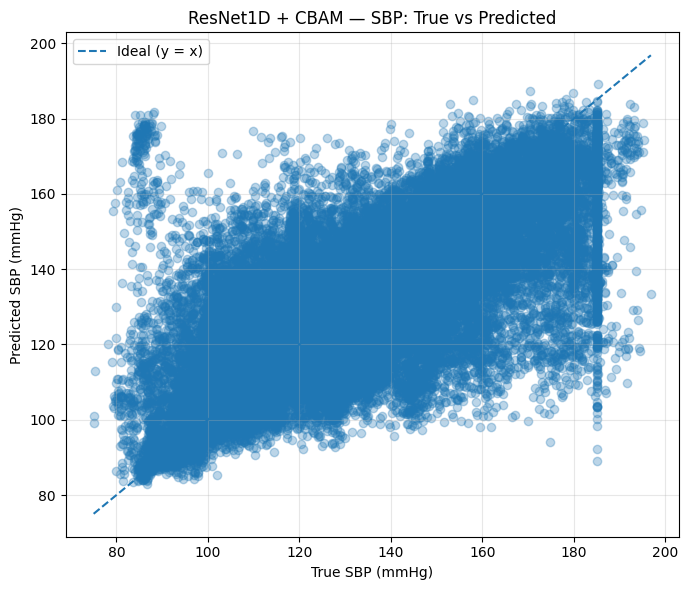

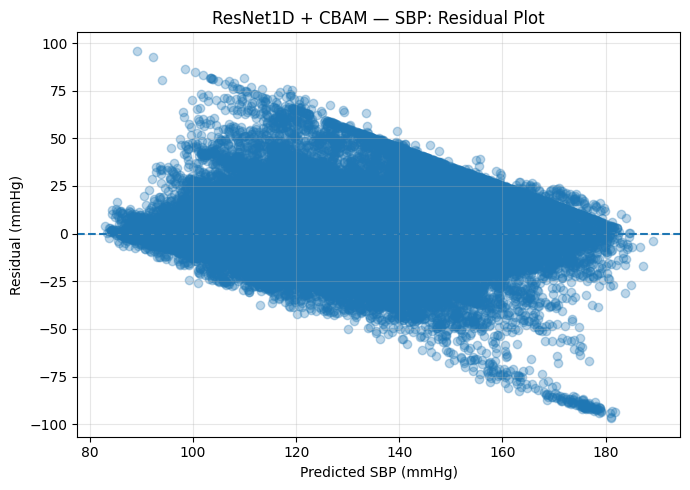

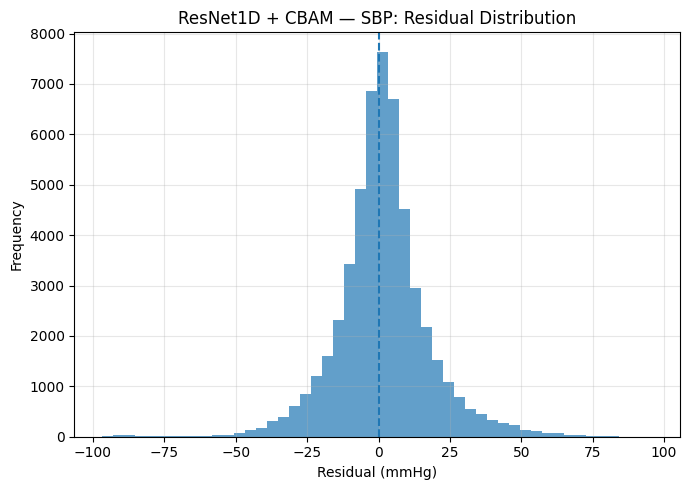

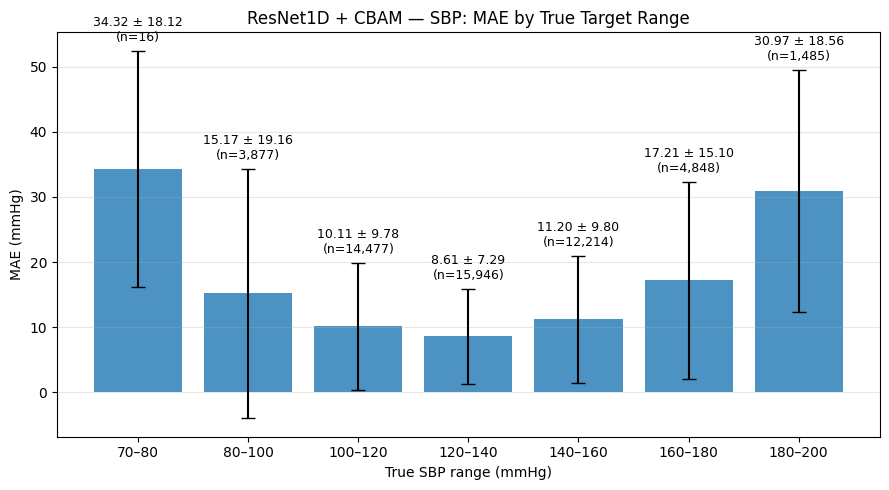

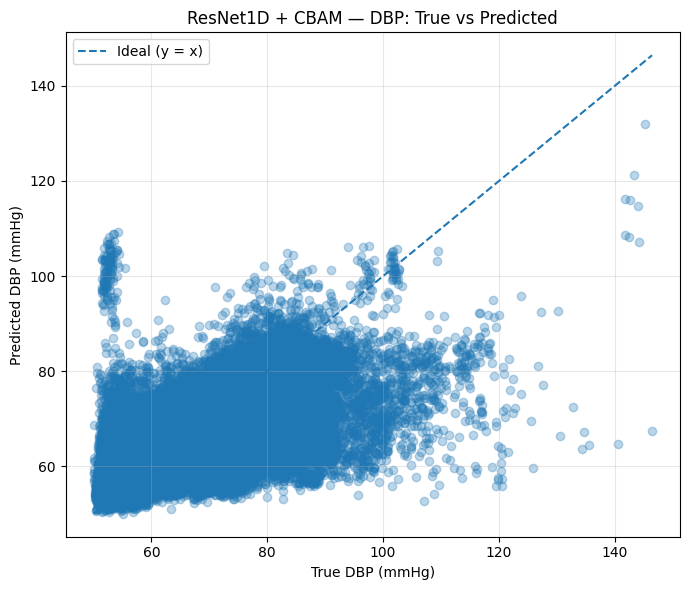

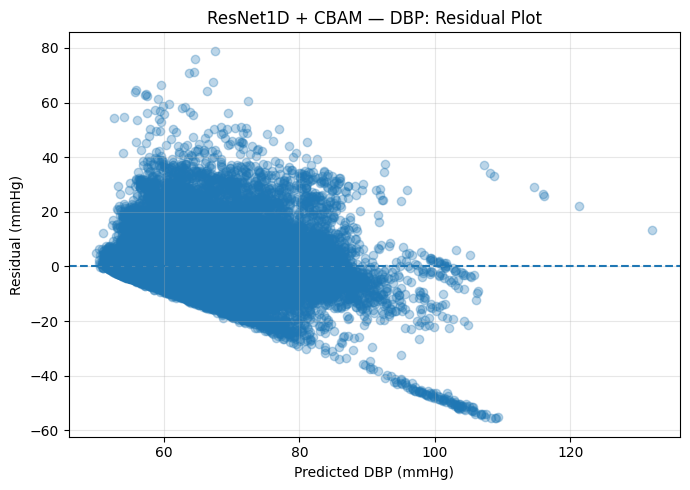

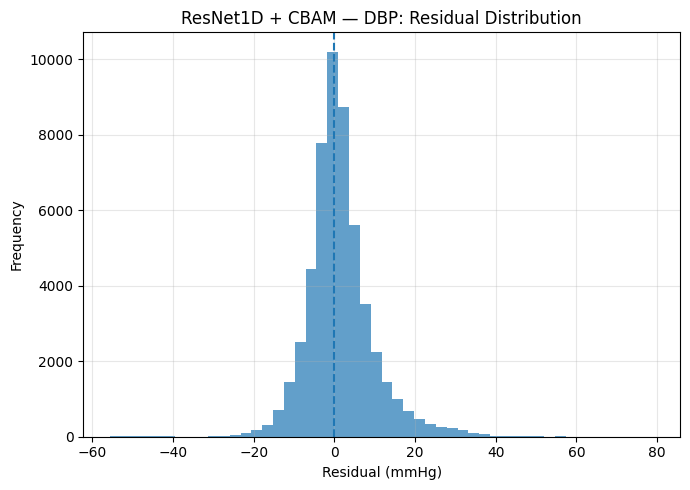

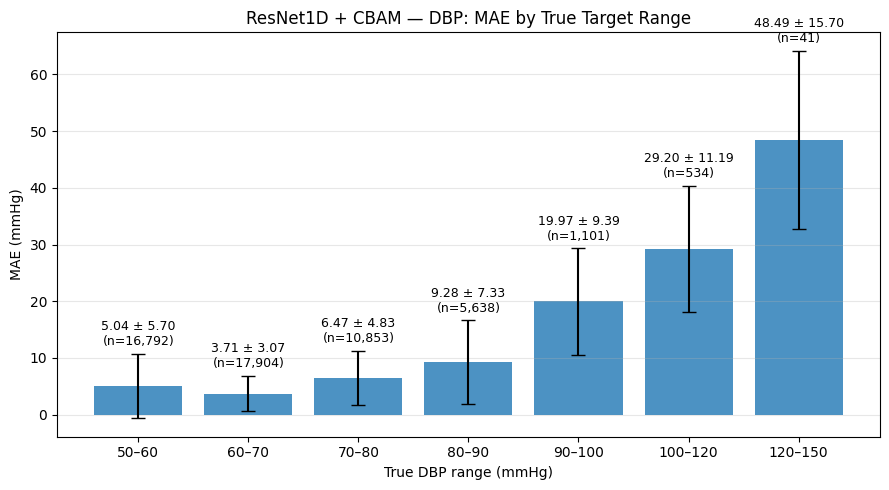

In [10]:
cbam_model, cbam_results = train_resnet1d_cbam(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

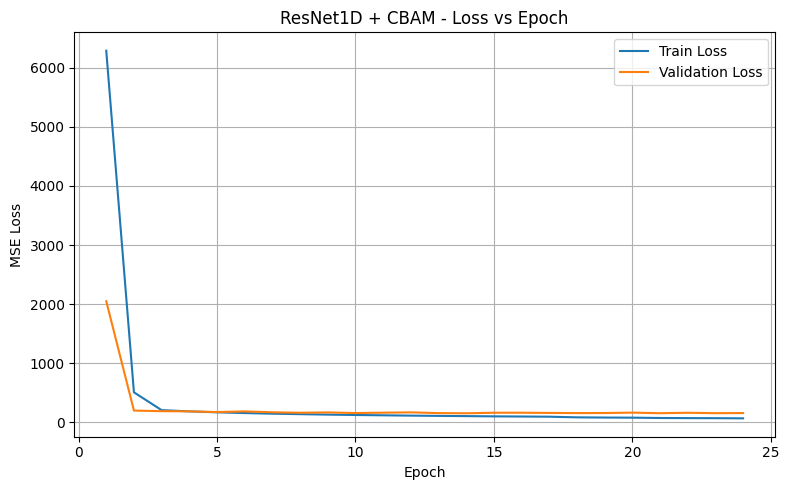

In [11]:
plot_loss_vs_epoch(
    cbam_results["history"],
    model_name="ResNet1D + CBAM"
)

Number of VitalDB cases: 1961


ResNet1D VitalDB prediction: 100%|██████████| 1961/1961 [05:48<00:00,  5.62case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 23.7925
MSE : 566.0826
R²  : -0.3286
MAE : 18.8751

DBP
RMSE: 13.7866
MSE : 190.0705
R²  : -0.1678
MAE : 10.8090


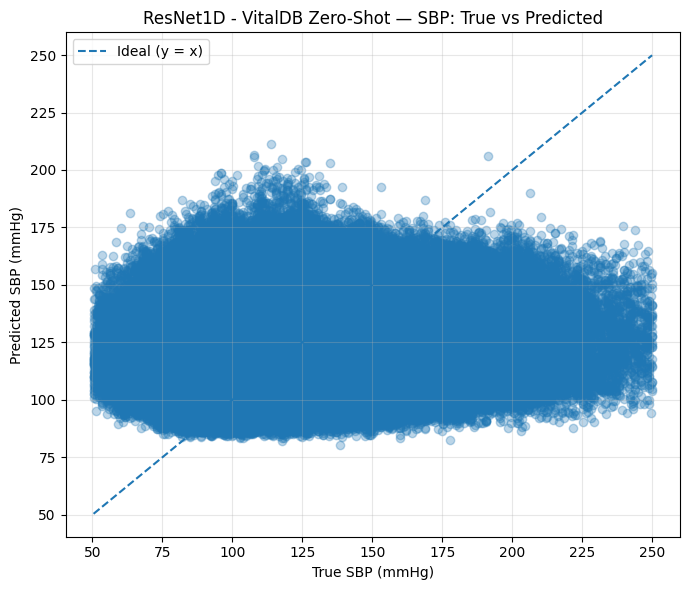

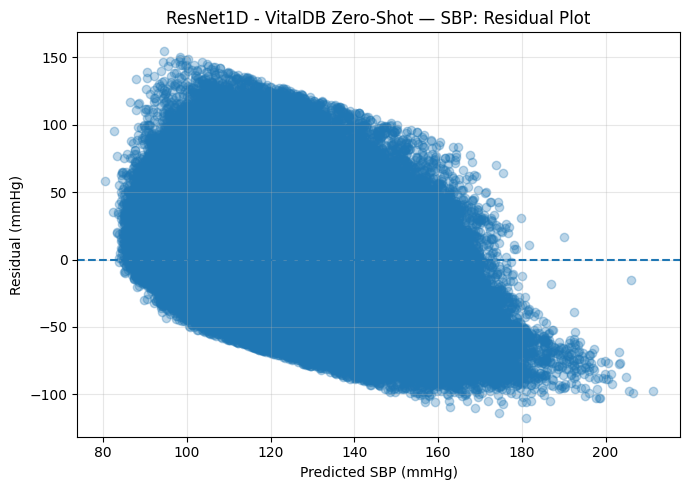

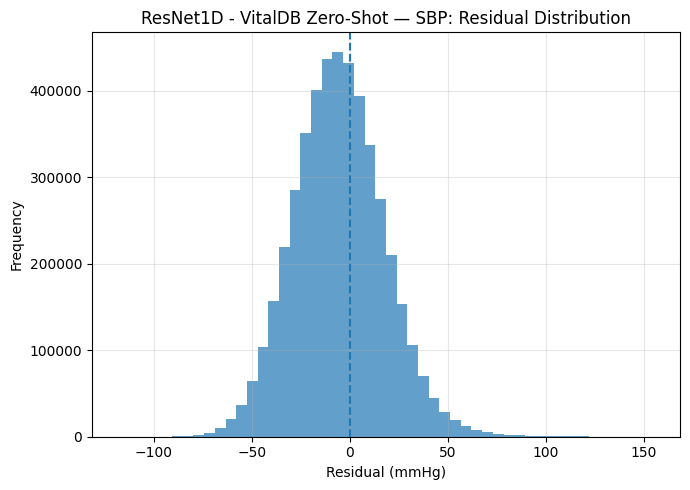

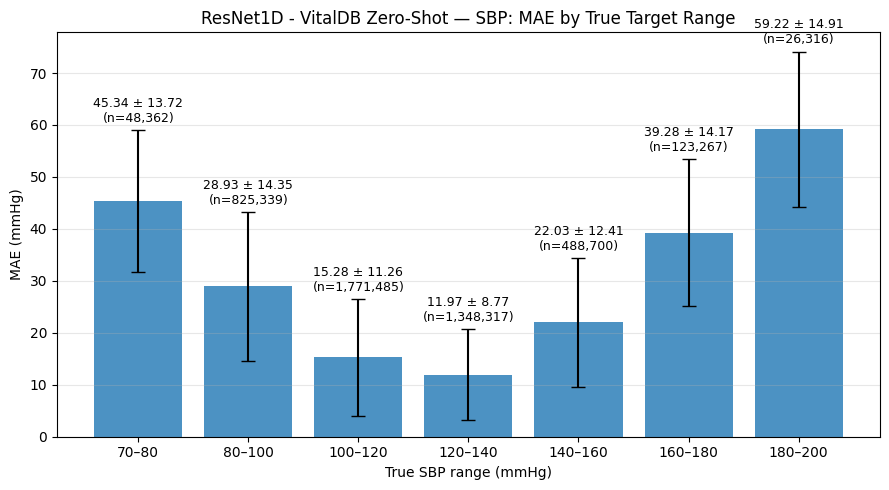

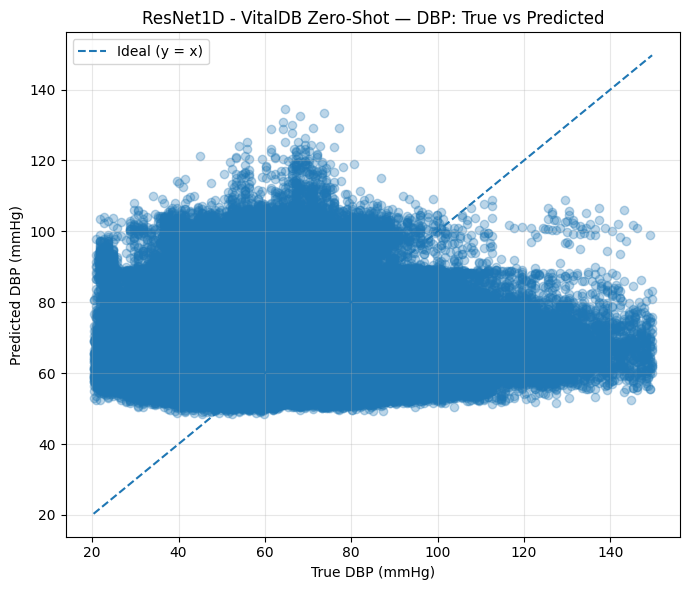

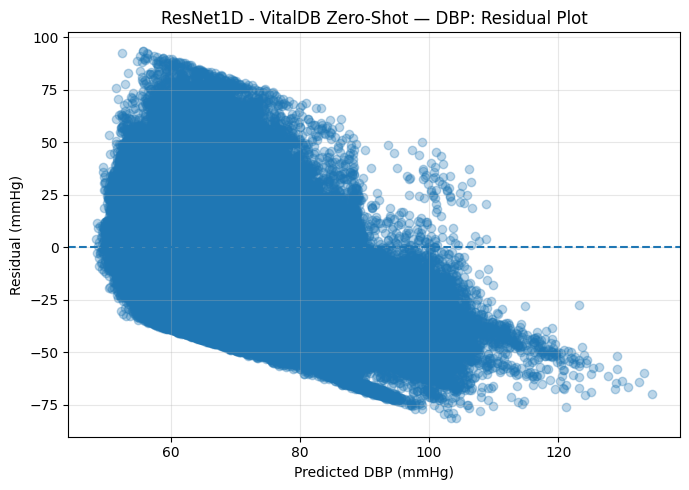

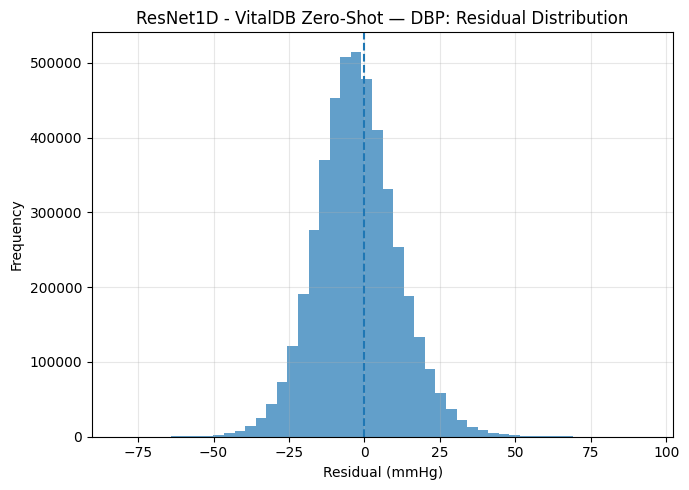

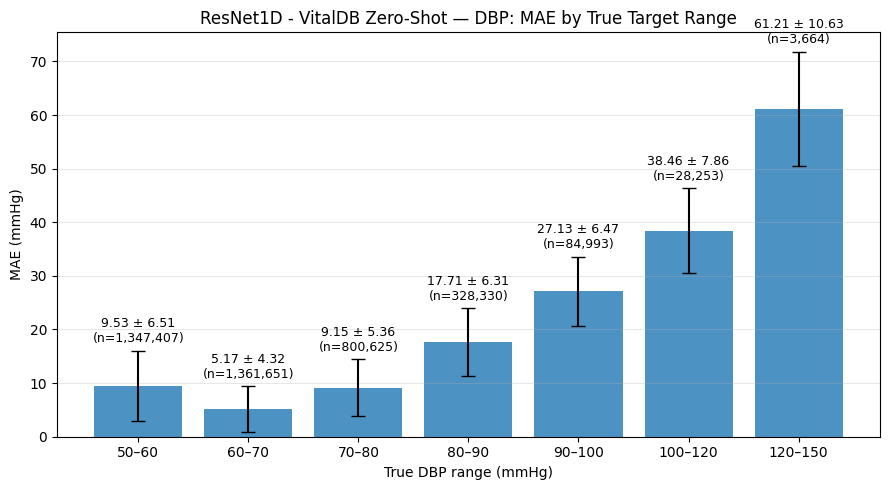

In [12]:
cbam_vitaldb_results = evaluate_resnet_vitaldb(
    model=cbam_model,
    base_dir=BASE_DIR,
    batch_size=256
)

## DILATED ## 

Device: cuda
X_train: torch.Size([417030, 1, 625])
X_val: torch.Size([52650, 1, 625])
X_test: torch.Size([52863, 1, 625])
Epoch 01/100 | Train Loss: 5396.9374 | Val Loss: 1340.0546 | Train SBP RMSE: 96.025 | Train DBP RMSE: 39.662 | Val SBP RMSE: 50.610 | Val DBP RMSE: 10.895 | LR: 1.00e-04
Epoch 02/100 | Train Loss: 416.7322 | Val Loss: 200.2883 | Train SBP RMSE: 27.018 | Train DBP RMSE: 10.173 | Val SBP RMSE: 17.695 | Val DBP RMSE: 9.351 | LR: 1.00e-04
Epoch 03/100 | Train Loss: 180.1379 | Val Loss: 177.6114 | Train SBP RMSE: 16.522 | Train DBP RMSE: 9.344 | Val SBP RMSE: 16.535 | Val DBP RMSE: 9.046 | LR: 1.00e-04
Epoch 04/100 | Train Loss: 165.9562 | Val Loss: 173.4766 | Train SBP RMSE: 15.825 | Train DBP RMSE: 9.028 | Val SBP RMSE: 16.360 | Val DBP RMSE: 8.904 | LR: 1.00e-04
Epoch 05/100 | Train Loss: 156.2879 | Val Loss: 169.9387 | Train SBP RMSE: 15.320 | Train DBP RMSE: 8.825 | Val SBP RMSE: 16.219 | Val DBP RMSE: 8.765 | LR: 1.00e-04
Epoch 06/100 | Train Loss: 148.2101 | Val L

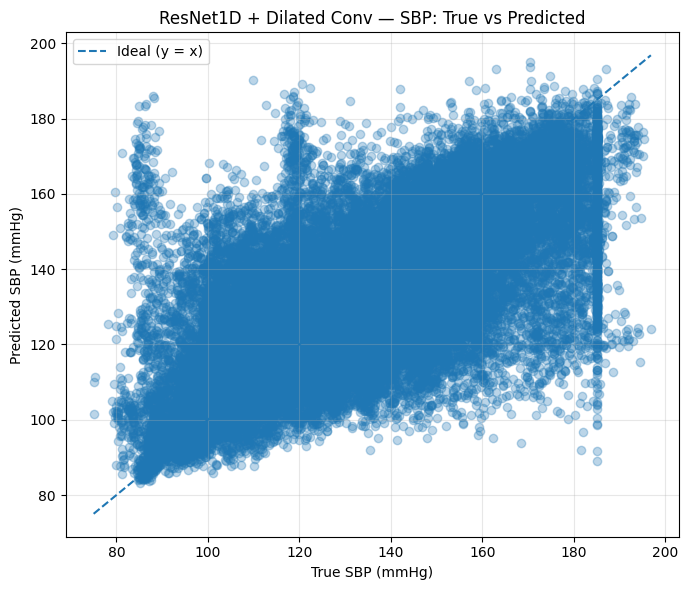

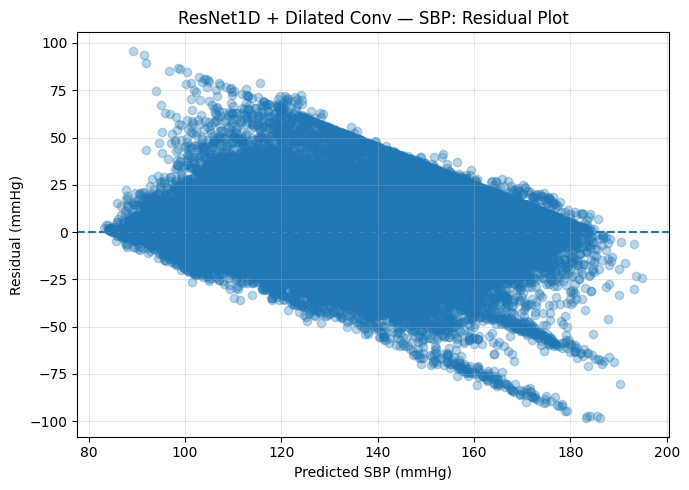

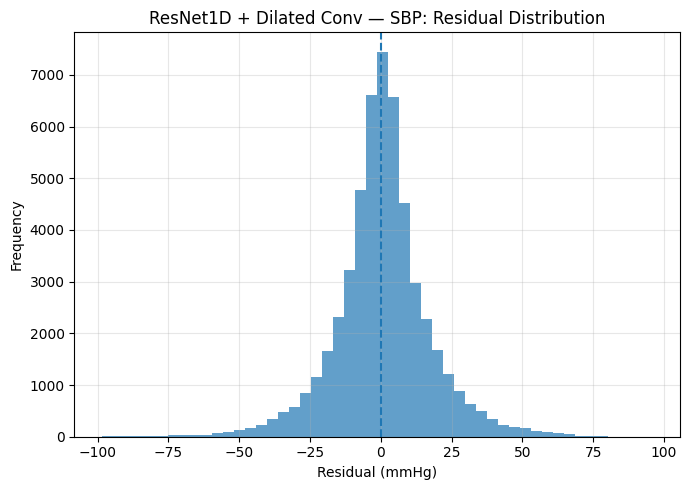

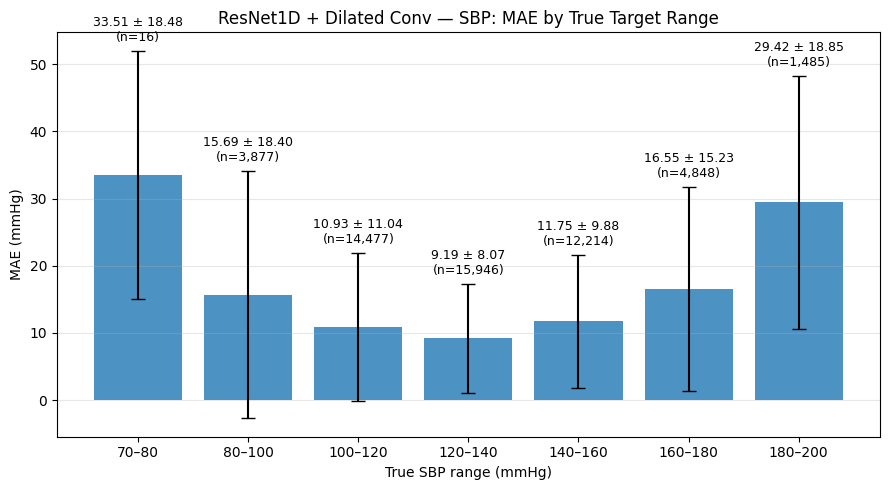

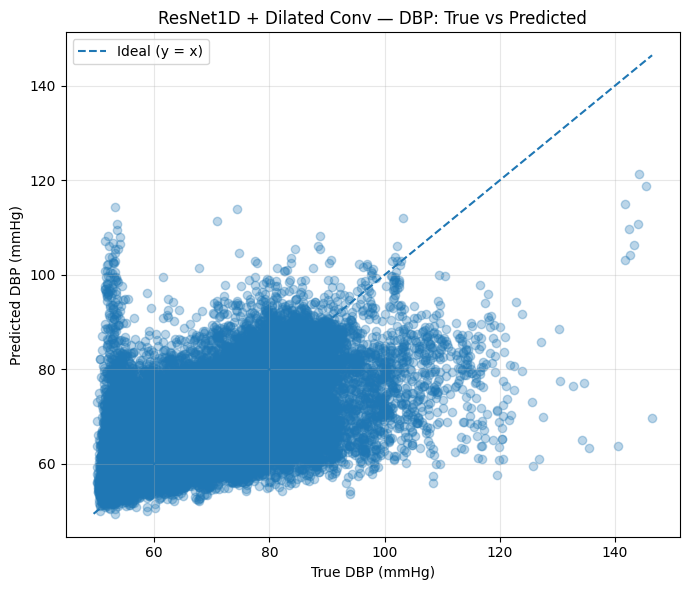

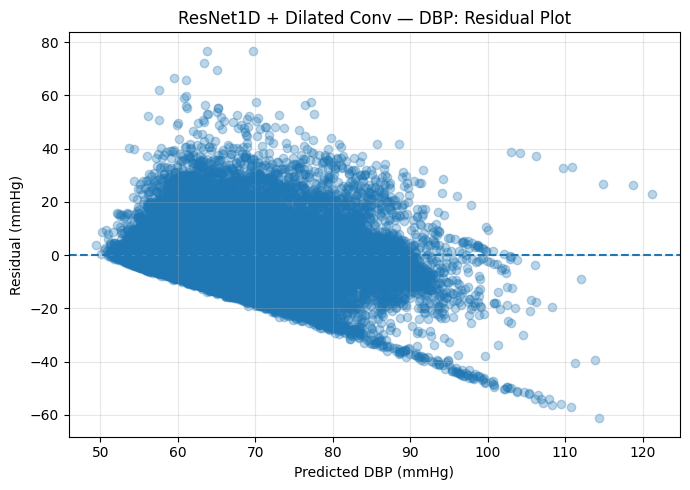

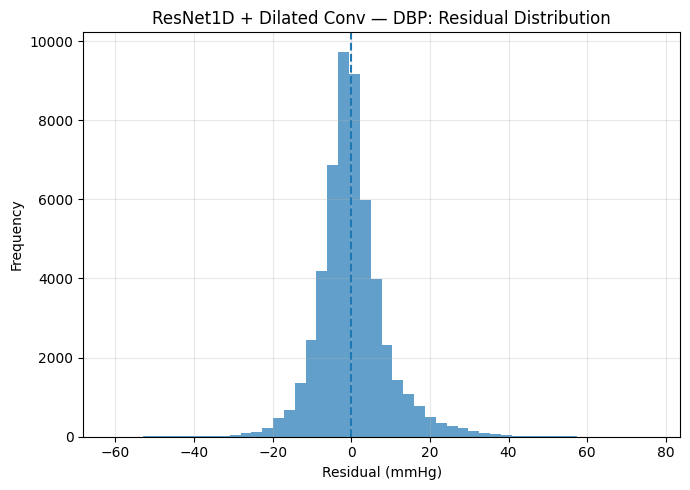

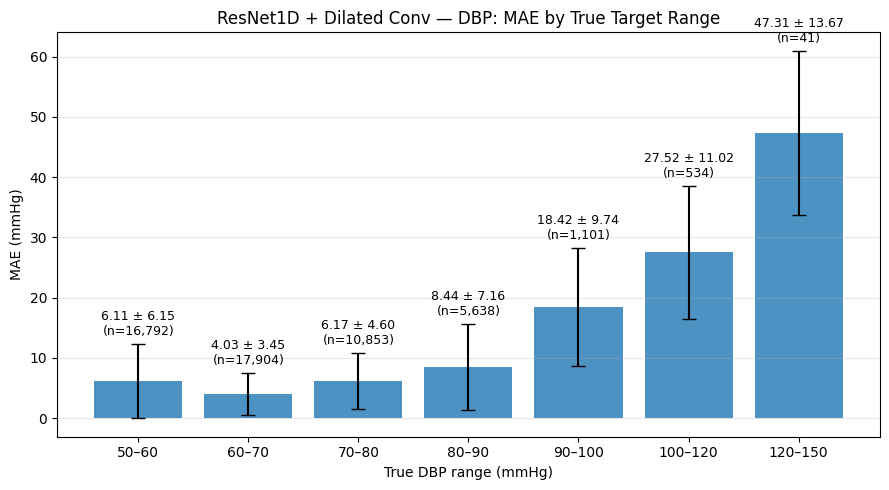

In [13]:
dilated_model, dilated_results = train_resnet1d_dilated(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=256,
    epochs=100,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10
)

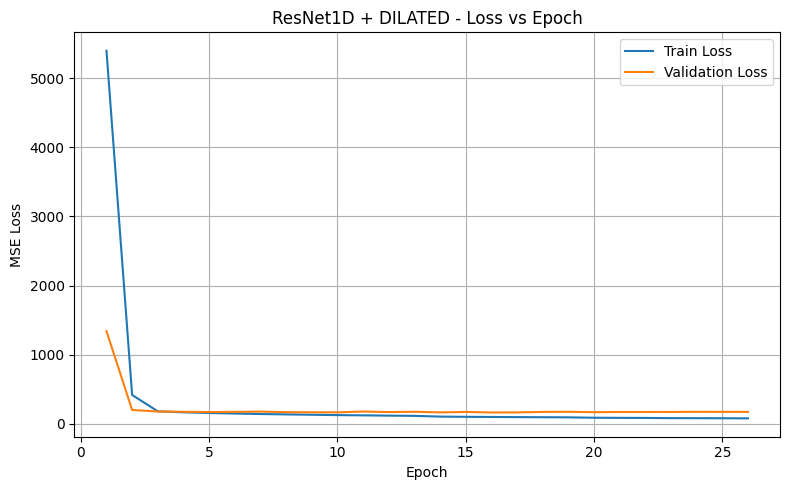

In [14]:
plot_loss_vs_epoch(
    dilated_results["history"],
    model_name="ResNet1D + DILATED"
)

Number of VitalDB cases: 1961


ResNet1D VitalDB prediction: 100%|██████████| 1961/1961 [04:33<00:00,  7.17case/s]



RESNET1D
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 25.8561
MSE : 668.5403
R²  : -0.5690
MAE : 20.5662

DBP
RMSE: 14.1401
MSE : 199.9429
R²  : -0.2284
MAE : 11.1982


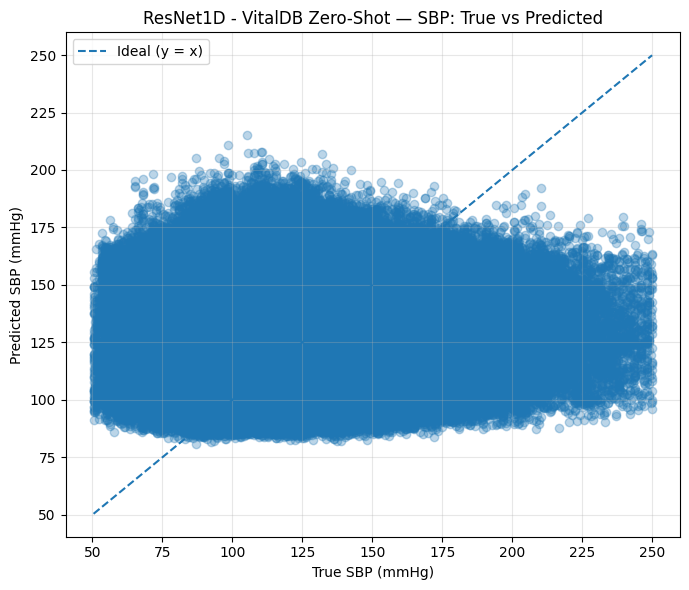

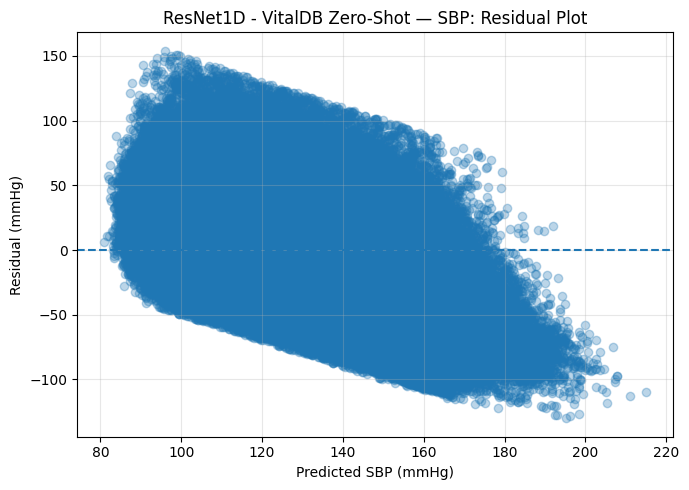

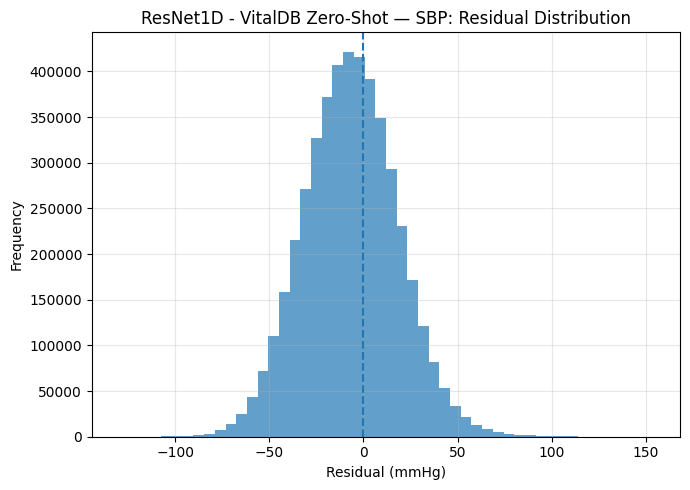

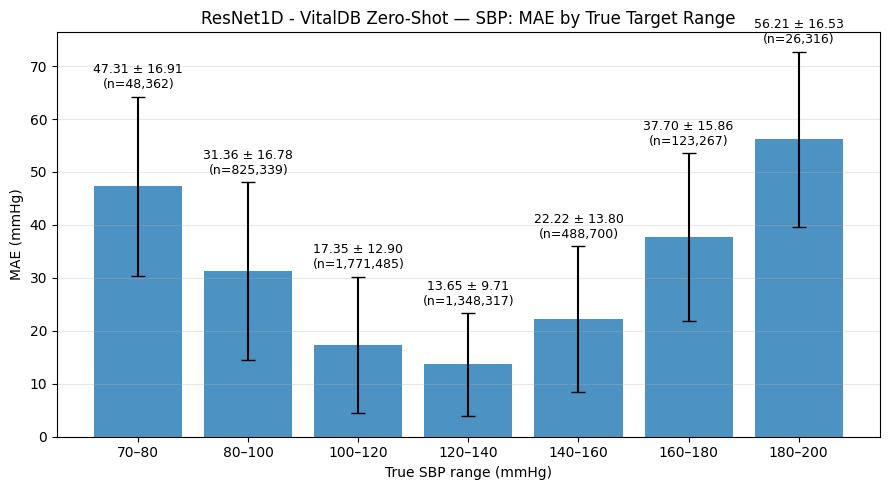

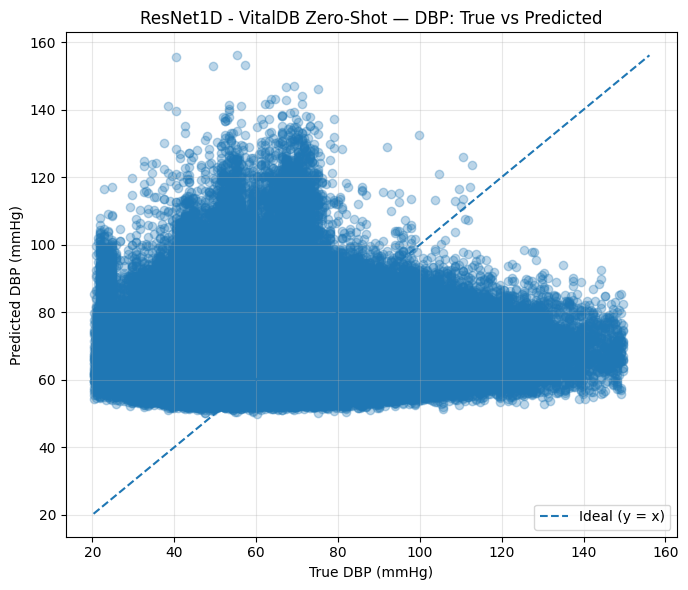

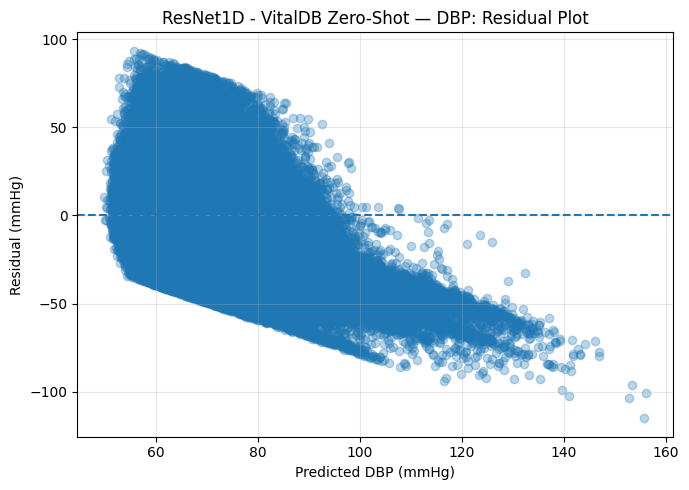

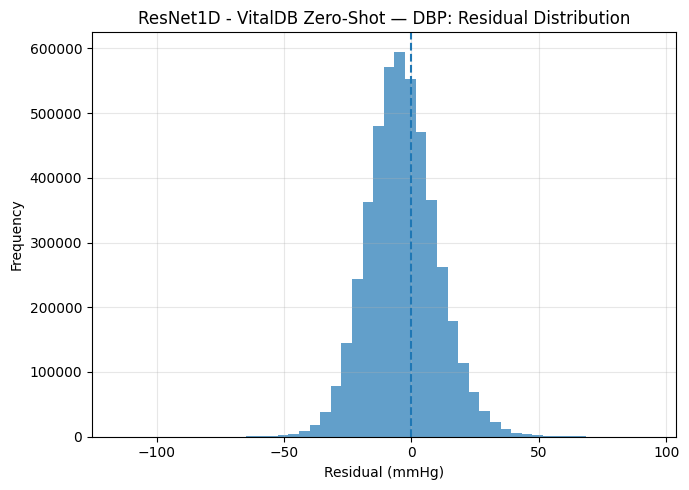

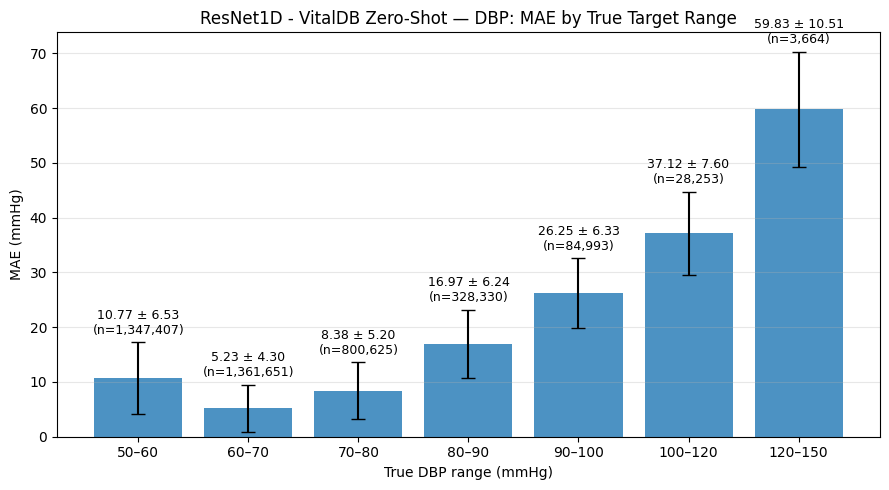

In [15]:
dilated_results = evaluate_resnet_vitaldb(
    model=dilated_model,
    base_dir=BASE_DIR,
    batch_size=256
)